<a href="https://colab.research.google.com/github/eunyeongkimm/ada_deeplearning/blob/main/ADA_ConvAE_3d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **심화과제 3-1: ConvAE with Bottleneck – 3D Latent Space**

3.1.2 실습의 FC 기반 3D AE를 기준 모델로 하여, ConvAE에 bottleneck layer를 추가한 3D latent dim 모델을 새로 설계·학습하고 두 모델의 성능을 4가지 지표로 비교

**비교 지표:**
1. 3D Latent Space Visualization
2. Silhouette Scores 비교
3. MSE Distribution 비교
4. Latent Interpolation 비교

## **Setup & Imports**

In [1]:
import tensorflow as tf
import keras
from keras import layers
from keras.constraints import max_norm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from scipy.stats import norm
from sklearn.metrics import silhouette_score

plt.rcParams['figure.figsize'] = [5, 3]
plt.rcParams['font.size'] = '8'
print(f'Keras version: {keras.__version__}')
print(f'TF version:    {tf.__version__}')

Keras version: 3.13.2
TF version:    2.19.0


## **Dataset: MNIST**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Flat  : (60000, 784) (10000, 784)
Conv  : (60000, 28, 28, 1) (10000, 28, 28, 1)


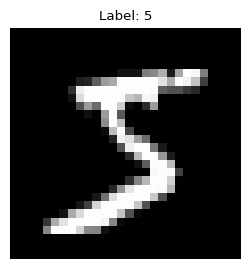

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize(픽셀 값 정규화)
x_train = x_train / 255.
x_test  = x_test  / 255.

# FC AE용 : 1차원으로 펼치기
x_train_flat = x_train.reshape(-1, 784)
x_test_flat  = x_test.reshape(-1, 784)

# conv AE용 : 2차원 유지
x_train_conv = x_train.reshape(-1, 28, 28, 1)
x_test_conv  = x_test.reshape(-1, 28, 28, 1)

print('Flat  :', x_train_flat.shape, x_test_flat.shape)
print('Conv  :', x_train_conv.shape, x_test_conv.shape)

plt.imshow(x_train[0], cmap='gray')
plt.title(f'Label: {y_train[0]}')
plt.axis('off')
plt.show()

---
## **Model 1: FC 3D AE (3.1.2 기준모델)**
-압축 : 784 → Dense(128) → Dense(32) → Dense(3)
-복원 : Dense(32) → Dense(128) → Dense(784)

In [3]:
m_norm = 1.0
encoding_dim_3d = 3

def encoder_3d():
    img = layers.Input(shape=(784,))
    x = layers.Dense(128, activation='relu',
                     kernel_constraint=max_norm(m_norm))(img)
    x = layers.Dense(32, activation='relu',
                     kernel_constraint=max_norm(m_norm))(x)
    x = layers.Dense(encoding_dim_3d, activation='linear',
                     kernel_constraint=max_norm(m_norm), name='enc_3d')(x)
    return keras.Model(img, x, name='fc_encoder')

def decoder_3d():
    dec_in = layers.Input(shape=(3,))
    x = layers.Dense(32, activation='relu',
                     kernel_constraint=max_norm(m_norm), name='dec_in_3d')(dec_in)
    x = layers.Dense(128, activation='relu',
                     kernel_constraint=max_norm(m_norm))(x)
    x = layers.Dense(784, activation='sigmoid',
                     kernel_constraint=max_norm(m_norm), name='dec_3d')(x)
    return keras.Model(dec_in, x, name='fc_decoder')

enc_model_fc = encoder_3d()
dec_model_fc = decoder_3d()

img_fc = layers.Input(shape=(784,))
AE_fc  = keras.Model(img_fc, dec_model_fc(enc_model_fc(img_fc)), name='FC_3D_AE')

AE_fc.summary()

Model: "FC_3D_AE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_encoder (Functional)         │ (None, 3)              │       104,707 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_decoder (Functional)         │ (None, 784)            │       105,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210,195 (821.07 KB)

 Trainable params: 210,195 (821.07 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# @title
%%time
epoch_n = 100
batch_size_n = 512

AE_fc.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')

history_fc = AE_fc.fit(
    x_train_flat, x_train_flat, verbose=2,
    epochs=epoch_n, batch_size=batch_size_n,
    validation_data=(x_test_flat, x_test_flat)
)

Epoch 1/100
118/118 - 18s - 155ms/step - loss: 0.0871 - val_loss: 0.0675
Epoch 2/100
118/118 - 0s - 3ms/step - loss: 0.0584 - val_loss: 0.0529
Epoch 3/100
118/118 - 0s - 3ms/step - loss: 0.0508 - val_loss: 0.0479
Epoch 4/100
118/118 - 0s - 3ms/step - loss: 0.0466 - val_loss: 0.0444
Epoch 5/100
118/118 - 0s - 3ms/step - loss: 0.0439 - val_loss: 0.0426
Epoch 6/100
118/118 - 0s - 3ms/step - loss: 0.0424 - val_loss: 0.0415
Epoch 7/100
118/118 - 0s - 3ms/step - loss: 0.0415 - val_loss: 0.0409
Epoch 8/100
118/118 - 0s - 3ms/step - loss: 0.0408 - val_loss: 0.0401
Epoch 9/100
118/118 - 0s - 3ms/step - loss: 0.0401 - val_loss: 0.0396
Epoch 10/100
118/118 - 0s - 3ms/step - loss: 0.0396 - val_loss: 0.0391
Epoch 11/100
118/118 - 0s - 3ms/step - loss: 0.0391 - val_loss: 0.0387
Epoch 12/100
118/118 - 0s - 3ms/step - loss: 0.0388 - val_loss: 0.0384
Epoch 13/100
118/118 - 0s - 3ms/step - loss: 0.0385 - val_loss: 0.0382
Epoch 14/100
118/118 - 0s - 3ms/step - loss: 0.0382 - val_loss: 0.0379
Epoch 15/100

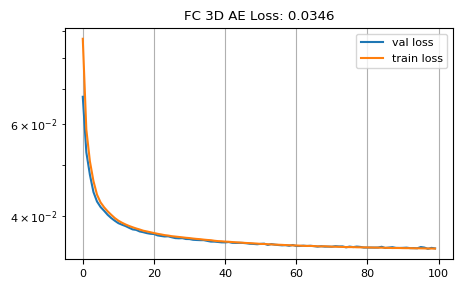

In [5]:
min_loss_fc = min(history_fc.history['val_loss'])
plt.title(f'FC 3D AE Loss: {min_loss_fc:.4f}')
plt.semilogy(history_fc.history['val_loss'], label='val loss')
plt.semilogy(history_fc.history['loss'], label='train loss')
plt.grid(); plt.legend()
plt.show()

---
## **Model 2: ConvAE with Bottleneck – 3D Latent (제안 모델)**

### 아키텍처 설계
- Encoder: Conv2D(32→64→128) + BatchNorm + MaxPooling으로 공간적 특징 추출 (28→14→7→4)
  - Conv2D: 이미지에서 선, 곡선, 패턴 등 공간적 특징을 감지
  - BatchNorm: Conv 레이어 출력값 분포를 안정화시켜 학습 초기 불안정 방지
  - MaxPooling: 이미지를 절반씩 줄여서 불필요한 세부 정보를 제거하고 전체적인 구조에 집중하게 만드는 효과

- Bottleneck: Flatten(2048) → Dense(256, relu) → Dense(3, linear)
  - Flatten 후 2048차원을 곧바로 3으로 압축하면 정보 손실이 너무 크기 때문에 Dense(256)을 중간에 두어 2단계로 나눠 압축
  - FC AE와 동일하게 max_norm(1.0) constraint 적용
   
    ** 각 뉴런의 weight vector 크기(L2 norm)가 1을 넘으면 강제로 1로 잘라냄

- Decoder: Dense → Reshape → Conv2DTranspose(stride=2)로 28×28 복원
  - 기존 UpSampling+Cropping 방식은 gradient 흐름을 방해해 학습 실패로 이어짐
  - Dense layer에 max_norm(1.0) constraint 적용
  - stride=2 Conv2DTranspose로 변경해 크기 확장과 특징 학습을 동시에 수행
  - 최종 32×32 출력을 Cropping2D로 28×28로 다듬음

- Learning rate: 0.001 → 0.0003으로 낮춤
  - FC AE(210K)보다 파라미터가 훨씬 많아(1.4M) 동일한 lr 사용 시 업데이트 폭이 너무 커 loss가 수렴하지 않았음

```
[Encoder]
Input(28,28,1)
  → Conv2D(32,3×3) + BatchNorm + MaxPool  → (14,14,32)
  → Conv2D(64,3×3) + BatchNorm + MaxPool  → (7,7,64)
  → Conv2D(128,3×3) + BatchNorm + MaxPool → (4,4,128)
  → Flatten                                → (2048,)
  → Dense(256, relu) + max_norm  ← Bottleneck
  → Dense(3, linear) + max_norm  ← 3D latent

[Decoder]
  → Dense(256, relu)  + max_norm  → (256,)
  → Dense(2048, relu) + max_norm  → (2048,)
  → Reshape                       → (4,4,128)
  → Conv2DTranspose(128, stride=2) → (8,8,128)
  → Conv2DTranspose(64,  stride=2) → (16,16,64)
  → Conv2DTranspose(32,  stride=2) → (32,32,32)
  → Cropping2D((2,2),(2,2))        → (28,28,32)
  → Conv2D(1, sigmoid)             → (28,28,1)
```

In [28]:
def conv_encoder_3d():
      inp = layers.Input(shape=(28, 28, 1), name='conv_enc_input')

      # Conv Block 1: 28x28 → 14x14
      x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inp)
      x = layers.BatchNormalization()(x)
      x = layers.MaxPooling2D((2,2), padding='same')(x)

      # Conv Block 2: 14x14 → 7x7
      x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
      x = layers.BatchNormalization()(x)
      x = layers.MaxPooling2D((2,2), padding='same')(x)

      # Conv Block 3: 7x7 → 4x4
      x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
      x = layers.BatchNormalization()(x)
      x = layers.MaxPooling2D((2,2), padding='same')(x)

      # Bottleneck: Flatten → Dense(256) → Dense(3)
      x = layers.Flatten()(x)                              #4*4*128 = 2048
      x = layers.Dense(256, activation='relu', kernel_constraint=max_norm(1.0), name='bottleneck')(x)
      z = layers.Dense(3, activation='linear', kernel_constraint=max_norm(1.0), name='latent_3d')(x)

      return keras.Model(inp, z, name='conv_encoder_3d')


def conv_decoder_3d():
      z_in = layers.Input(shape=(3,), name='conv_dec_input')

      x = layers.Dense(256, activation='relu', kernel_constraint=max_norm(1.0))(z_in)
      x = layers.Dense(4*4*128, activation='relu', kernel_constraint=max_norm(1.0))(x)
      x = layers.Reshape((4, 4, 128))(x)

      # 4x4 → 8x8 → 16x16 → 32x32
      x = layers.Conv2DTranspose(128, (3,3), strides=2, activation='relu', padding='same')(x)
      x = layers.Conv2DTranspose(64,  (3,3), strides=2, activation='relu', padding='same')(x)
      x = layers.Conv2DTranspose(32,  (3,3), strides=2, activation='relu', padding='same')(x)
      x = layers.Cropping2D(((2,2),(2,2)))(x)  # 32x32 → 28x28

      out = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same', name='recon')(x)

      return keras.Model(z_in, out, name='conv_decoder_3d')


# Build full ConvAE
enc_model_cv = conv_encoder_3d()
dec_model_cv = conv_decoder_3d()

img_cv = layers.Input(shape=(28, 28, 1))
AE_cv  = keras.Model(img_cv, dec_model_cv(enc_model_cv(img_cv)),name='ConvAE_3D')

print('=== Encoder ===')
enc_model_cv.summary()
print('\n=== Full AE ===')
AE_cv.summary()

=== Encoder ===


Model: "conv_encoder_3d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_enc_input (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_3d (Dense)               │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 618,883 (2.36 MB)

 Trainable params: 618,435 (2.36 MB)

...

Model: "ConvAE_3D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_encoder_3d (Functional)    │ (None, 3)              │       618,883 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_decoder_3d (Functional)    │ (None, 28, 28, 1)      │       767,489 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,386,372 (5.29 MB)

 Trainable params: 1,385,924 (5.29 MB)

 Non-trainable params: 448 (1.75 KB)

In [29]:
%%time
# lr을 낮추기
AE_cv.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0003), loss='mse')

history_cv = AE_cv.fit(
    x_train_conv, x_train_conv, verbose=2,
    epochs=epoch_n, batch_size=batch_size_n,
    validation_data=(x_test_conv, x_test_conv)
)

Epoch 1/100
118/118 - 10s - 88ms/step - loss: 0.0814 - val_loss: 0.1528
Epoch 2/100
118/118 - 1s - 5ms/step - loss: 0.0523 - val_loss: 0.0632
Epoch 3/100
118/118 - 1s - 5ms/step - loss: 0.0431 - val_loss: 0.0523
Epoch 4/100
118/118 - 1s - 5ms/step - loss: 0.0400 - val_loss: 0.0417
Epoch 5/100
118/118 - 1s - 5ms/step - loss: 0.0378 - val_loss: 0.0388
Epoch 6/100
118/118 - 1s - 5ms/step - loss: 0.0364 - val_loss: 0.0363
Epoch 7/100
118/118 - 1s - 5ms/step - loss: 0.0353 - val_loss: 0.0353
Epoch 8/100
118/118 - 1s - 5ms/step - loss: 0.0344 - val_loss: 0.0348
Epoch 9/100
118/118 - 1s - 5ms/step - loss: 0.0338 - val_loss: 0.0341
Epoch 10/100
118/118 - 1s - 5ms/step - loss: 0.0332 - val_loss: 0.0336
Epoch 11/100
118/118 - 1s - 5ms/step - loss: 0.0328 - val_loss: 0.0331
Epoch 12/100
118/118 - 1s - 5ms/step - loss: 0.0324 - val_loss: 0.0328
Epoch 13/100
118/118 - 1s - 5ms/step - loss: 0.0321 - val_loss: 0.0326
Epoch 14/100
118/118 - 1s - 5ms/step - loss: 0.0317 - val_loss: 0.0321
Epoch 15/100


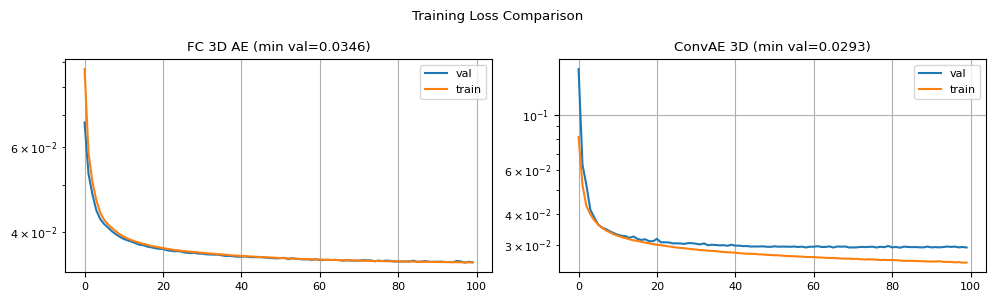

In [30]:
min_loss_cv = min(history_cv.history['val_loss'])

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].semilogy(history_fc.history['val_loss'], label='val')
axes[0].semilogy(history_fc.history['loss'],     label='train')
axes[0].set_title(f'FC 3D AE (min val={min(history_fc.history["val_loss"]):.4f})')
axes[0].legend(); axes[0].grid()

axes[1].semilogy(history_cv.history['val_loss'], label='val')
axes[1].semilogy(history_cv.history['loss'],     label='train')
axes[1].set_title(f'ConvAE 3D (min val={min_loss_cv:.4f})')
axes[1].legend(); axes[1].grid()

plt.suptitle('Training Loss Comparison')
plt.tight_layout()
plt.show()

---
## **비교 분석 1: 3D Latent Space Visualization**

In [31]:
z_test_fc = enc_model_fc.predict(x_test_flat, verbose=0)
z_test_cv = enc_model_cv.predict(x_test_conv, verbose=0)

print('FC  3D latent shape:', z_test_fc.shape)
print('Conv 3D latent shape:', z_test_cv.shape)

FC  3D latent shape: (10000, 3)
Conv 3D latent shape: (10000, 3)


In [32]:
# FC 3D AE - Interactive 3D Latent Space
df_fc = pd.DataFrame({
    'z0': z_test_fc[:, 0],
    'z1': z_test_fc[:, 1],
    'z2': z_test_fc[:, 2],
    'label': y_test.astype(str)
})
fig = px.scatter_3d(df_fc, x='z0', y='z1', z='z2', color='label',
                    title='FC 3D AE: Interactive 3D Latent Space')
fig.update_traces(marker=dict(size=1))
fig.show()

In [33]:
# ConvAE 3D - Interactive 3D Latent Space
df_cv = pd.DataFrame({
    'z0': z_test_cv[:, 0],
    'z1': z_test_cv[:, 1],
    'z2': z_test_cv[:, 2],
    'label': y_test.astype(str)
})
fig = px.scatter_3d(df_cv, x='z0', y='z1', z='z2', color='label',
                    title='ConvAE 3D: Interactive 3D Latent Space')
fig.update_traces(marker=dict(size=1))
fig.show()

In [40]:
z_test_cv = enc_model_cv.predict(x_test_conv, verbose=0)

print(f'z0 범위: {z_test_cv[:,0].min():.1f} ~ {z_test_cv[:,0].max():.1f}')
print(f'z1 범위: {z_test_cv[:,1].min():.1f} ~ {z_test_cv[:,1].max():.1f}')
print(f'z2 범위: {z_test_cv[:,2].min():.1f} ~ {z_test_cv[:,2].max():.1f}')

z0 범위: -17.7 ~ 22.7
z1 범위: -21.3 ~ 19.7
z2 범위: -30.9 ~ 14.5


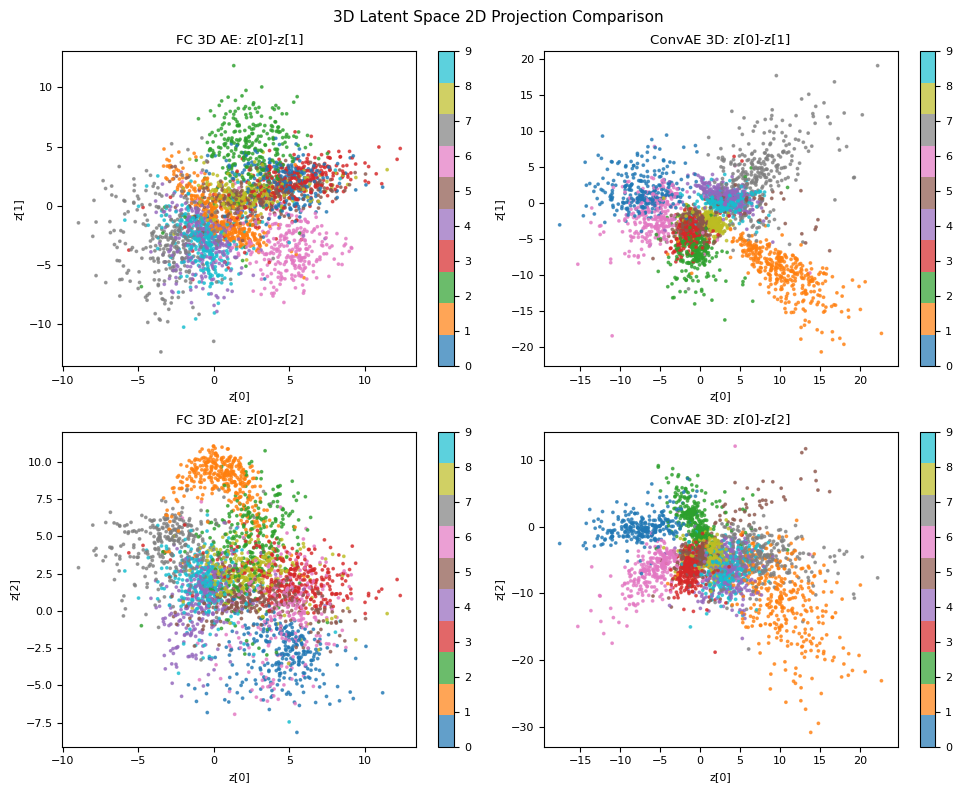

In [34]:
# 2D 투영 비교 (z0-z1, z0-z2)
n_plot = 3000
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for col, (z, title) in enumerate([(z_test_fc, 'FC 3D AE'), (z_test_cv, 'ConvAE 3D')]):
    sc = axes[0, col].scatter(z[:n_plot, 0], z[:n_plot, 1],
                               c=y_test[:n_plot], cmap='tab10', s=3, alpha=0.7)
    axes[0, col].set_xlabel('z[0]'); axes[0, col].set_ylabel('z[1]')
    axes[0, col].set_title(f'{title}: z[0]-z[1]')
    plt.colorbar(sc, ax=axes[0, col])

    sc2 = axes[1, col].scatter(z[:n_plot, 0], z[:n_plot, 2],
                                c=y_test[:n_plot], cmap='tab10', s=3, alpha=0.7)
    axes[1, col].set_xlabel('z[0]'); axes[1, col].set_ylabel('z[2]')
    axes[1, col].set_title(f'{title}: z[0]-z[2]')
    plt.colorbar(sc2, ax=axes[1, col])

plt.suptitle('3D Latent Space 2D Projection Comparison', fontsize=11)
plt.tight_layout()
plt.show()

## **비교 분석 2: Silhouette Scores**

In [41]:
def conv_encoder_2d():
    inp = layers.Input(shape=(28, 28, 1), name='conv_enc_input')

    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2), padding='same')(x)

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2), padding='same')(x)

    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2), padding='same')(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_constraint=max_norm(1.0), name='bottleneck')(x)
    z = layers.Dense(2, activation='linear',          # ← 3→2로 변경
                     kernel_constraint=max_norm(1.0), name='latent_2d')(x)

    return keras.Model(inp, z, name='conv_encoder_2d')


def conv_decoder_2d():
    z_in = layers.Input(shape=(2,), name='conv_dec_input')  # ← 3→2로 변경

    x = layers.Dense(256, activation='relu',
                     kernel_constraint=max_norm(1.0))(z_in)
    x = layers.Dense(4*4*128, activation='relu',
                     kernel_constraint=max_norm(1.0))(x)
    x = layers.Reshape((4, 4, 128))(x)

    x = layers.Conv2DTranspose(128, (3,3), strides=2, activation='relu', padding='same')(x)
    x = layers.Conv2DTranspose(64,  (3,3), strides=2, activation='relu', padding='same')(x)
    x = layers.Conv2DTranspose(32,  (3,3), strides=2, activation='relu', padding='same')(x)
    x = layers.Cropping2D(((2,2),(2,2)))(x)

    out = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same', name='recon')(x)
    return keras.Model(z_in, out, name='conv_decoder_2d')


# Build
enc_model_cv2d = conv_encoder_2d()
dec_model_cv2d = conv_decoder_2d()

img_cv2d = layers.Input(shape=(28, 28, 1))
AE_cv2d  = keras.Model(img_cv2d,
                        dec_model_cv2d(enc_model_cv2d(img_cv2d)),
                        name='ConvAE_2D')

AE_cv2d.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0003),
                loss='mse')

history_cv2d = AE_cv2d.fit(
    x_train_conv, x_train_conv, verbose=2,
    epochs=100, batch_size=512,
    validation_data=(x_test_conv, x_test_conv)
)

Epoch 1/100
118/118 - 15s - 129ms/step - loss: 0.0883 - val_loss: 0.1969
Epoch 2/100
118/118 - 1s - 5ms/step - loss: 0.0591 - val_loss: 0.0631
Epoch 3/100
118/118 - 1s - 5ms/step - loss: 0.0534 - val_loss: 0.0610
Epoch 4/100
118/118 - 1s - 5ms/step - loss: 0.0507 - val_loss: 0.0539
Epoch 5/100
118/118 - 1s - 5ms/step - loss: 0.0489 - val_loss: 0.0484
Epoch 6/100
118/118 - 1s - 5ms/step - loss: 0.0468 - val_loss: 0.0460
Epoch 7/100
118/118 - 1s - 5ms/step - loss: 0.0446 - val_loss: 0.0440
Epoch 8/100
118/118 - 1s - 5ms/step - loss: 0.0430 - val_loss: 0.0430
Epoch 9/100
118/118 - 1s - 5ms/step - loss: 0.0418 - val_loss: 0.0418
Epoch 10/100
118/118 - 1s - 5ms/step - loss: 0.0408 - val_loss: 0.0411
Epoch 11/100
118/118 - 1s - 5ms/step - loss: 0.0401 - val_loss: 0.0401
Epoch 12/100
118/118 - 1s - 5ms/step - loss: 0.0394 - val_loss: 0.0395
Epoch 13/100
118/118 - 1s - 5ms/step - loss: 0.0389 - val_loss: 0.0392
Epoch 14/100
118/118 - 1s - 5ms/step - loss: 0.0386 - val_loss: 0.0389
Epoch 15/100

In [42]:
# 2D latent 뽑기
z_test_cv2d = enc_model_cv2d.predict(x_test_conv, verbose=0)

# Silhouette Score
silhouette_cv2d = silhouette_score(z_test_cv2d, y_test)
print(f'Silhouette Score (ConvAE 2D): {silhouette_cv2d:.4f}')

Silhouette Score (ConvAE 2D): 0.0854


In [43]:
silhouette_cv = silhouette_score(z_test_cv, y_test)
print(f'Silhouette Score (ConvAE 3D) : {silhouette_cv:.4f}')

Silhouette Score (ConvAE 3D) : 0.1418


## **비교 분석 3: MSE Distribution**

Mean MSE (FC 3D AE)  : 0.03462
Mean MSE (ConvAE 3D) : 0.02940
Improvement          : 15.1%


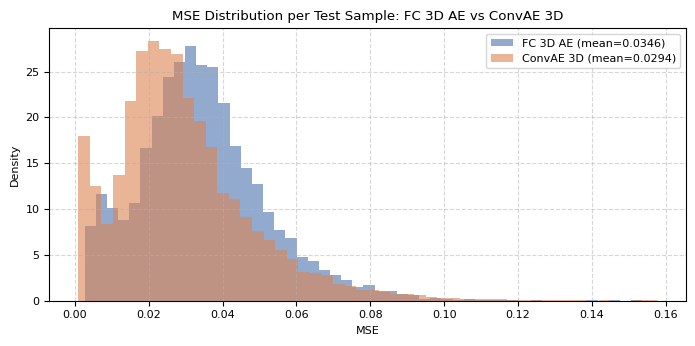

In [36]:
# Reconstruct
x_recon_fc = AE_fc.predict(x_test_flat, verbose=0)
x_recon_cv = AE_cv.predict(x_test_conv, verbose=0).reshape(-1, 784)

# Per-sample MSE
mse_fc = np.mean(np.square(x_test_flat - x_recon_fc), axis=1)
mse_cv = np.mean(np.square(x_test_flat - x_recon_cv), axis=1)

print(f'Mean MSE (FC 3D AE)  : {np.mean(mse_fc):.5f}')
print(f'Mean MSE (ConvAE 3D) : {np.mean(mse_cv):.5f}')
print(f'Improvement          : {(np.mean(mse_fc)-np.mean(mse_cv))/np.mean(mse_fc)*100:.1f}%')

# Distribution plot
plt.figure(figsize=(7, 3.5))
plt.hist(mse_fc, bins=50, alpha=0.6,
         label=f'FC 3D AE (mean={np.mean(mse_fc):.4f})', density=True, color='#4C72B0')
plt.hist(mse_cv, bins=50, alpha=0.6,
         label=f'ConvAE 3D (mean={np.mean(mse_cv):.4f})', density=True, color='#DD8452')
plt.xlabel('MSE'); plt.ylabel('Density')
plt.title('MSE Distribution per Test Sample: FC 3D AE vs ConvAE 3D')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

MSE Statistics per Digit Class:
Digit  |    FC Mean |    CV Mean |  Improvement
------------------------------------------------
0      |    0.03490 |    0.02895 |        17.0%
1      |    0.01053 |    0.00600 |        43.0%
2      |    0.04764 |    0.04080 |        14.4%
3      |    0.04184 |    0.03554 |        15.1%
4      |    0.03589 |    0.03021 |        15.8%
5      |    0.04308 |    0.03979 |         7.6%
6      |    0.03478 |    0.02848 |        18.1%
7      |    0.02634 |    0.02343 |        11.0%
8      |    0.04620 |    0.03869 |        16.3%
9      |    0.02933 |    0.02636 |        10.1%


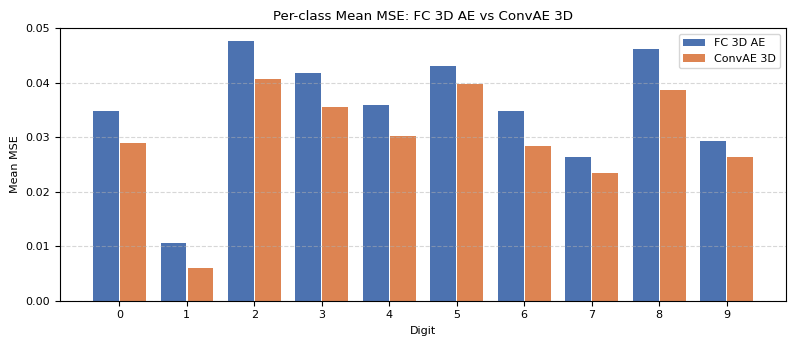

In [37]:
# Per-class MSE statistics
mean_mse_fc = {}; mean_mse_cv = {}
var_mse_fc  = {}; var_mse_cv  = {}

for digit in range(10):
    idx = (y_test == digit)
    mean_mse_fc[digit] = np.mean(mse_fc[idx])
    var_mse_fc[digit]  = np.var(mse_fc[idx])
    mean_mse_cv[digit] = np.mean(mse_cv[idx])
    var_mse_cv[digit]  = np.var(mse_cv[idx])

print('MSE Statistics per Digit Class:')
print(f'{"Digit":<6} | {"FC Mean":>10} | {"CV Mean":>10} | {"Improvement":>12}')
print('-'*48)
for d in range(10):
    imp = (mean_mse_fc[d]-mean_mse_cv[d])/mean_mse_fc[d]*100
    print(f'{d:<6} | {mean_mse_fc[d]:>10.5f} | {mean_mse_cv[d]:>10.5f} | {imp:>11.1f}%')

# Per-class bar chart
x_pos = np.arange(10)
plt.figure(figsize=(8, 3.5))
plt.bar(x_pos-0.2, list(mean_mse_fc.values()), 0.38, label='FC 3D AE',  color='#4C72B0')
plt.bar(x_pos+0.2, list(mean_mse_cv.values()), 0.38, label='ConvAE 3D', color='#DD8452')
plt.xticks(x_pos, range(10)); plt.xlabel('Digit'); plt.ylabel('Mean MSE')
plt.title('Per-class Mean MSE: FC 3D AE vs ConvAE 3D')
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## **비교 분석 4: Latent Interpolation (Narrow z0 Sampling)**

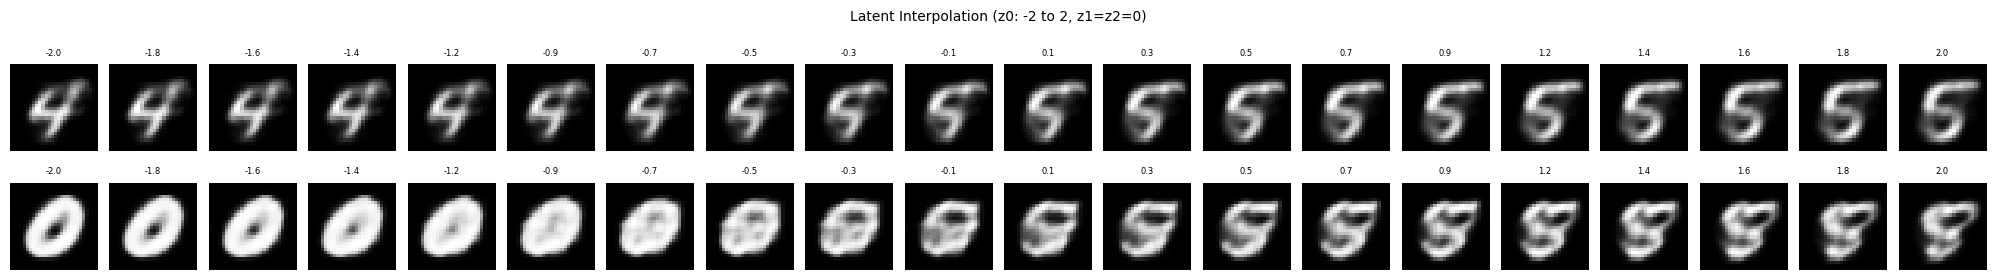

In [38]:
n_sample = 20
z0_range = np.linspace(-2, 2, n_sample)

# FC 3D AE interpolation
z_input_fc = np.column_stack((z0_range, np.zeros(n_sample), np.zeros(n_sample)))
decoded_fc  = dec_model_fc.predict(z_input_fc, verbose=0).reshape(n_sample, 28, 28)

# ConvAE 3D interpolation
z_input_cv = np.column_stack((z0_range, np.zeros(n_sample), np.zeros(n_sample)))
decoded_cv  = dec_model_cv.predict(z_input_cv, verbose=0).reshape(n_sample, 28, 28)

fig, axes = plt.subplots(2, n_sample, figsize=(20, 3))
for i in range(n_sample):
    axes[0, i].imshow(decoded_fc[i], cmap='gray'); axes[0, i].axis('off')
    axes[0, i].set_title(f'{z0_range[i]:.1f}', fontsize=6)
    axes[1, i].imshow(decoded_cv[i], cmap='gray'); axes[1, i].axis('off')
    axes[1, i].set_title(f'{z0_range[i]:.1f}', fontsize=6)

axes[0, 0].set_ylabel('FC 3D AE', fontsize=8)
axes[1, 0].set_ylabel('ConvAE 3D', fontsize=8)
fig.suptitle('Latent Interpolation (z0: -2 to 2, z1=z2=0)', fontsize=10)
plt.tight_layout()
plt.show()

## **2D Grid Decoding Visualization (z2=0 고정)**

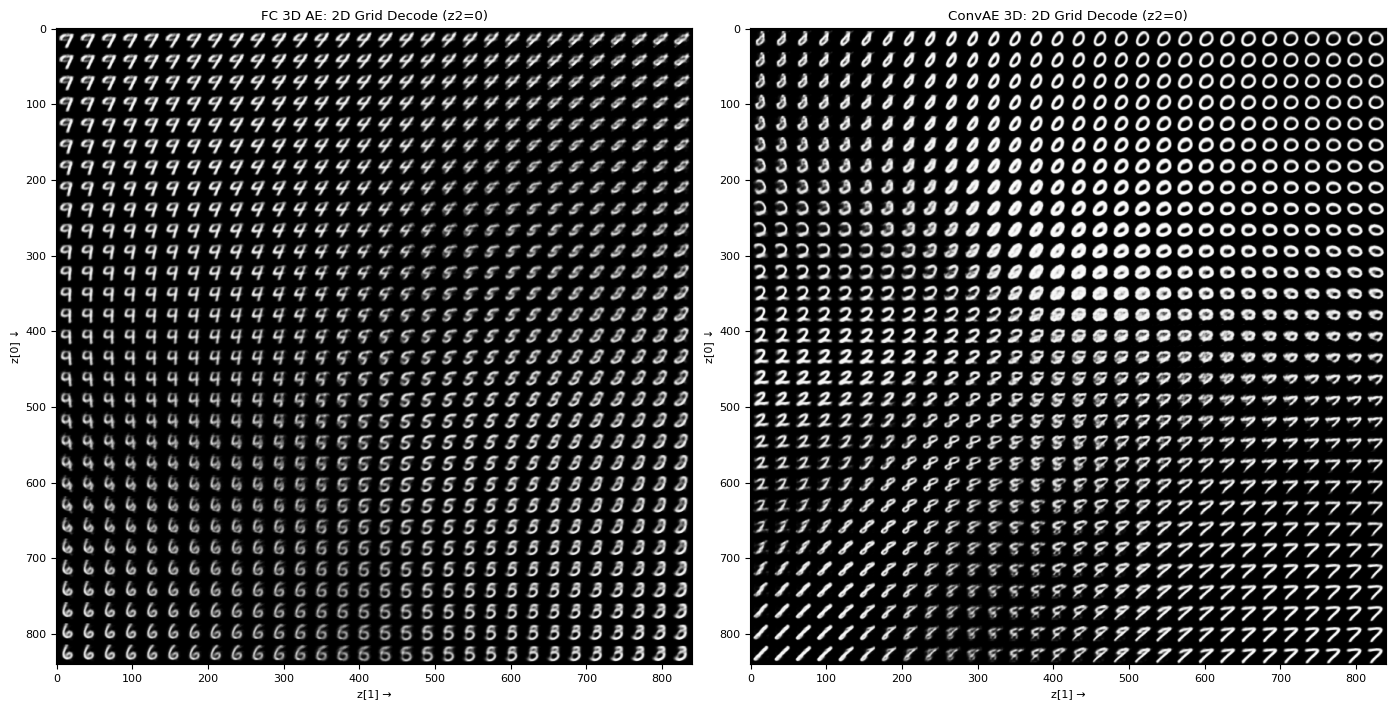

In [39]:
n = 30; digit_size = 28
grid_x = np.linspace(-5, 5, n)
grid_y = np.linspace(-5, 5, n)

figure_fc = np.zeros((digit_size * n, digit_size * n))
figure_cv = np.zeros((digit_size * n, digit_size * n))

for i, xi in enumerate(grid_x):
    for j, yi in enumerate(grid_y):
        z_s = np.array([[xi, yi, 0.0]])
        figure_fc[i*digit_size:(i+1)*digit_size, j*digit_size:(j+1)*digit_size] = \
            dec_model_fc.predict(z_s, batch_size=1, verbose=0)[0].reshape(digit_size, digit_size)
        figure_cv[i*digit_size:(i+1)*digit_size, j*digit_size:(j+1)*digit_size] = \
            dec_model_cv.predict(z_s, batch_size=1, verbose=0)[0].reshape(digit_size, digit_size)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(figure_fc, cmap='Greys_r'); axes[0].set_title('FC 3D AE: 2D Grid Decode (z2=0)')
axes[1].imshow(figure_cv, cmap='Greys_r'); axes[1].set_title('ConvAE 3D: 2D Grid Decode (z2=0)')
for ax in axes: ax.set_xlabel('z[1] →'); ax.set_ylabel('z[0] ↓')
plt.tight_layout()
plt.show()

## **Reconstruction Comparison**

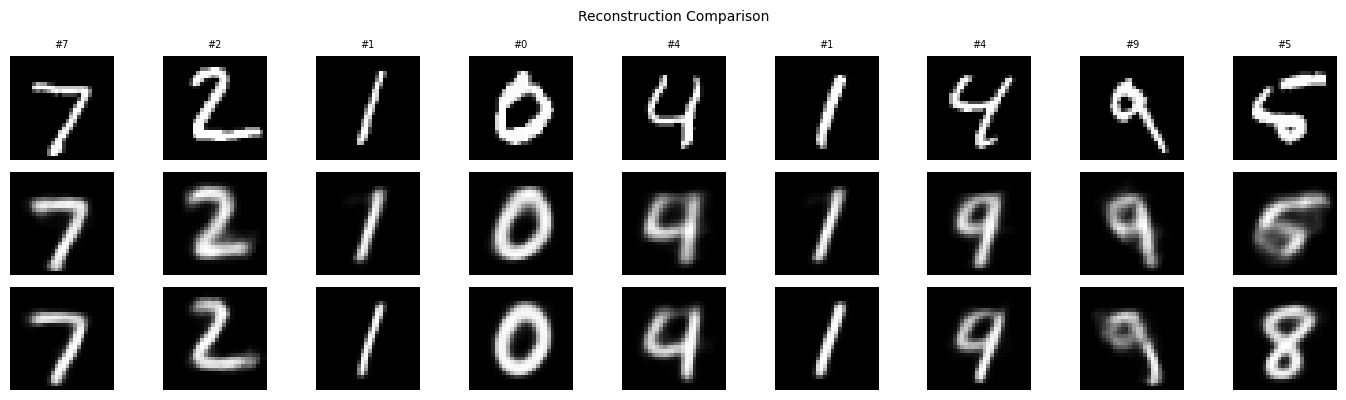

In [24]:
num_imgs = 9
orig = x_test_flat[:num_imgs].reshape(num_imgs, 28, 28)
rfc  = x_recon_fc[:num_imgs].reshape(num_imgs, 28, 28)
rcv  = x_recon_cv[:num_imgs].reshape(num_imgs, 28, 28)

fig, axes = plt.subplots(3, num_imgs, figsize=(14, 4))
for i in range(num_imgs):
    axes[0, i].imshow(orig[i], cmap='gray'); axes[0, i].axis('off'); axes[0, i].set_title(f'#{y_test[i]}', fontsize=7)
    axes[1, i].imshow(rfc[i],  cmap='gray'); axes[1, i].axis('off')
    axes[2, i].imshow(rcv[i],  cmap='gray'); axes[2, i].axis('off')
axes[0, 0].set_ylabel('Original',  fontsize=8)
axes[1, 0].set_ylabel('FC 3D AE',  fontsize=8)
axes[2, 0].set_ylabel('ConvAE 3D', fontsize=8)
fig.suptitle('Reconstruction Comparison', fontsize=10)
plt.tight_layout()
plt.show()